# Raman Basic Spectra Analysis

Cleaned workflow: load data, build raw/norm/scaled, heatmap, spectra plots, Excel export, DE export.

In [97]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from scipy import sparse
from matplotlib import colors as mcolors
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment

In [98]:
output_fig2 = Path("./results/figure2")
output_figS3 = Path("./results/figureS3")
output_fig2.mkdir(parents=True, exist_ok=True)
output_figS3.mkdir(parents=True, exist_ok=True)

In [99]:
raman_adata = sc.read_h5ad("./data/raman_B.h5ad")
raman_adata

AnnData object with n_obs × n_vars = 1415 × 432
    obs: 'cell_type'

In [100]:
# Build scaled matrix following the provided pipeline
adata_work = raman_adata.copy()
adata_work.layers["raw"] = adata_work.X.copy()

# Normalization
sc.pp.normalize_total(adata_work, target_sum=1e4)
sc.pp.log1p(adata_work)
adata_work.layers["norm"] = adata_work.X.copy()

# Scale (z-score)
sc.pp.scale(adata_work)
# After scaling, adata_work.X is the scaled matrix

In [101]:
def _get_layer_matrix(adata, layer=None):
    if layer is None:
        X = adata.X
    else:
        X = adata.layers[layer]
    if sparse.issparse(X):
        X = X.toarray()
    return X

def _get_wavenumbers(adata):
    w = pd.to_numeric(pd.Index(adata.var.index), errors="coerce")
    if w.isna().any():
        raise ValueError("Some var.index values are not numeric wavenumbers.")
    return w

def _subset_wavenumber_range(adata, wn_min=600, wn_max=1800):
    w = _get_wavenumbers(adata)
    mask = (w >= wn_min) & (w <= wn_max)
    return mask, w[mask]

def build_spectra_df(adata, layer=None, wn_min=600, wn_max=1800):
    mask, w_subset = _subset_wavenumber_range(adata, wn_min, wn_max)
    X = _get_layer_matrix(adata, layer=layer)
    X = X[:, mask]
    df = pd.DataFrame(X, columns=w_subset)
    df["cell_type"] = adata.obs["cell_type"].astype(str).values
    df = pd.melt(df, id_vars="cell_type", var_name="Wavenumber", value_name="Intensity")
    df["Wavenumber"] = pd.to_numeric(df["Wavenumber"], errors="coerce")
    return df

In [102]:
# Global class order and colors (hard-coded to match LDA plots)
ORDER = ["HSC", "Pro B", "Pre B", "Naive B"]
class_color_map = {
    "HSC": "#1f77b4",    # blue
    "Pro B": "#17becf",  # cyan
    "Pre B": "#e377c2",  # pink
    "Naive B": "#d62728" # red
}
classes = np.array(ORDER)
adata_work.obs["cell_type"] = pd.Categorical(adata_work.obs["cell_type"], categories=classes, ordered=True)
adata_work.uns["cell_type_colors"] = [class_color_map[c] for c in classes]

highlight_ranges = [(950, 1000), (1400, 1700)]

## Heatmap (600�C1800 cm^-1, 50 cm^-1 bins)

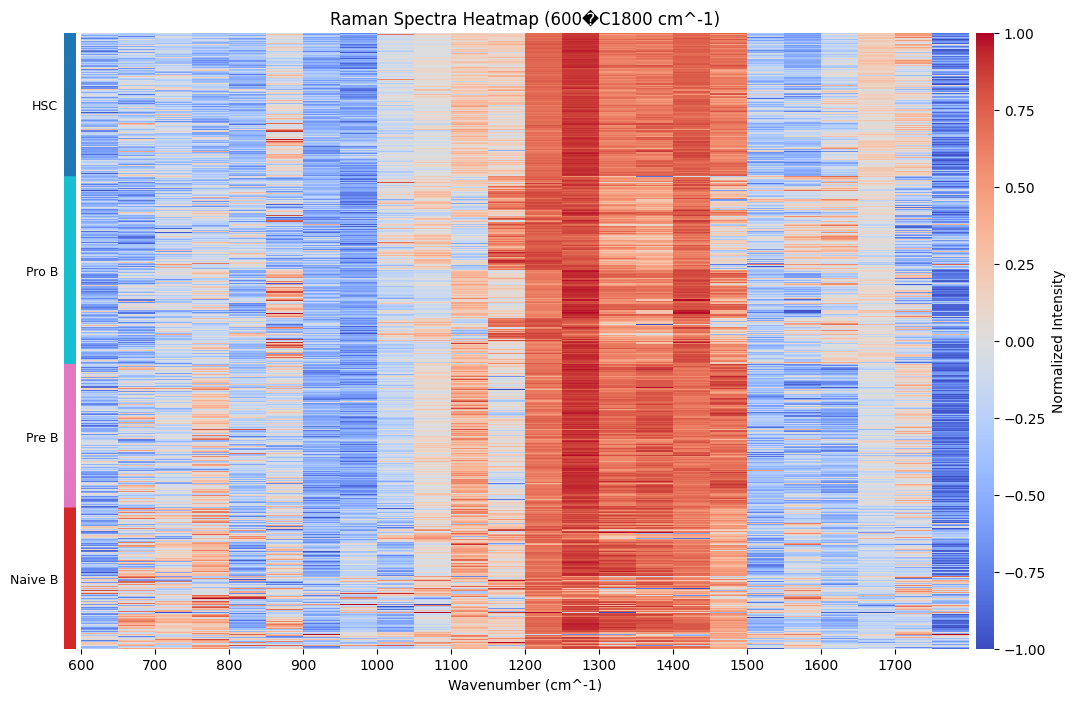

In [103]:
mask, w_subset = _subset_wavenumber_range(adata_work, 600, 1800)
X = _get_layer_matrix(adata_work, layer="norm" if "norm" in adata_work.layers else None)
X = X[:, mask]

# Bin every 50 cm^-1 by averaging columns
bin_size = 50
bins = (w_subset.values // bin_size) * bin_size
unique_bins = np.sort(np.unique(bins))
X_binned = np.zeros((X.shape[0], len(unique_bins)))
for i, b in enumerate(unique_bins):
    X_binned[:, i] = X[:, bins == b].mean(axis=1)

# Normalize to [-1, 1] per binned wavenumber
scaler = MinMaxScaler(feature_range=(-1, 1))
X_norm = scaler.fit_transform(X_binned)

# Order cells by cell_type
cell_type = adata_work.obs["cell_type"].astype(str).values
order = np.argsort(pd.Categorical(cell_type, categories=ORDER, ordered=True).codes)
X_plot = X_norm[order, :]
cell_type_sorted = cell_type[order]

# Row color strip for cell types (RGBA)
row_colors = np.array([mcolors.to_rgba(class_color_map[ct]) for ct in cell_type_sorted])

fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[0.012, 0.968, 0.02], wspace=0.02)
ax_color = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

ax_color.imshow(row_colors.reshape(-1, 1, 4), aspect="auto")
ax_color.set_xticks([])
ax_color.set_yticks([])
for spine in ax_color.spines.values():
    spine.set_visible(False)

sns.heatmap(X_plot, cmap="coolwarm", vmin=-1, vmax=1, cbar=True, cbar_ax=cax,
            cbar_kws={"label": "Normalized Intensity"},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title("Raman Spectra Heatmap (600�C1800 cm^-1)")
ax.set_xlabel("Wavenumber (cm^-1)")
ax.set_ylabel("")

tick_bins = [int(b) for b in unique_bins if b % 100 == 0]
tick_idx = [np.where(unique_bins == b)[0][0] for b in tick_bins]
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_bins, rotation=0)

group_bounds = []
start = 0
for ct in ORDER:
    count = np.sum(cell_type_sorted == ct)
    end = start + count
    group_bounds.append((ct, start, end))
    start = end

ax_color.set_yticks([(s + e) / 2 for (_, s, e) in group_bounds])
ax_color.set_yticklabels([ct for (ct, _, __) in group_bounds], fontsize=9)
ax_color.yaxis.set_ticks_position("left")
ax_color.tick_params(axis="y", length=0, pad=4)

for ext in ["pdf", "svg", "png"]:
    plt.savefig(output_fig2 / f"raman_heatmap.{ext}", dpi=300, bbox_inches="tight")
plt.show()

## Facet Spectra (Raw / Scaled)

In [104]:
def plot_facet_spectra_summary(df, title, highlight_ranges=None, output_dir=None, fname=None, color_map=None, order=None):
    agg = df.groupby(["cell_type", "Wavenumber"]).agg(
        mean_intensity=("Intensity", "mean"),
        std_intensity=("Intensity", "std")
    ).reset_index()

    if order is None:
        cell_types = sorted(agg["cell_type"].unique())
    else:
        cell_types = [ct for ct in order if ct in agg["cell_type"].unique()]

    if color_map is None:
        palette = sns.color_palette("tab10", n_colors=len(cell_types))
        color_map = {ct: palette[i] for i, ct in enumerate(cell_types)}

    n = len(cell_types)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 2.6 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, ct in zip(axes, cell_types):
        sub = agg[agg["cell_type"] == ct]
        ax.plot(sub["Wavenumber"], sub["mean_intensity"], color=color_map.get(ct, "black"), linewidth=2.0)
        ax.fill_between(sub["Wavenumber"],
                        sub["mean_intensity"] - sub["std_intensity"],
                        sub["mean_intensity"] + sub["std_intensity"],
                        color="#B0B0B0", alpha=0.35)

        if highlight_ranges:
            for start, end in highlight_ranges:
                ax.axvspan(start, end, color="#7FB3D5", alpha=0.18)

        ax.set_ylabel(ct)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)

    axes[-1].set_xlabel("Wavenumber (cm^-1)")
    axes[-1].set_xlim(600, 1800)
    axes[-1].set_xticks(np.arange(600, 1801, 100))
    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()

    if output_dir is not None and fname is not None:
        for ext in ["pdf", "svg", "png"]:
            fig.savefig(output_dir / f"{fname}.{ext}", dpi=300, bbox_inches="tight")

    plt.show()
    return color_map

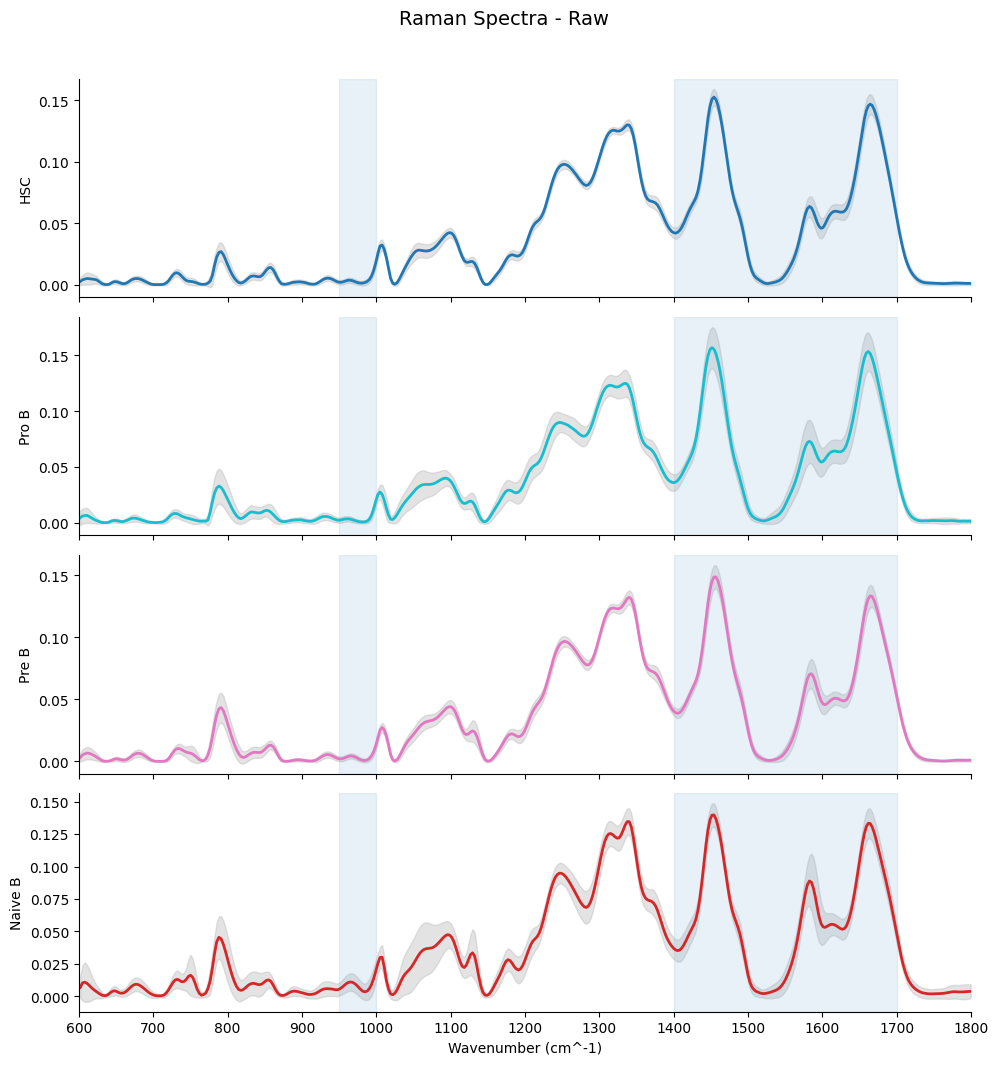

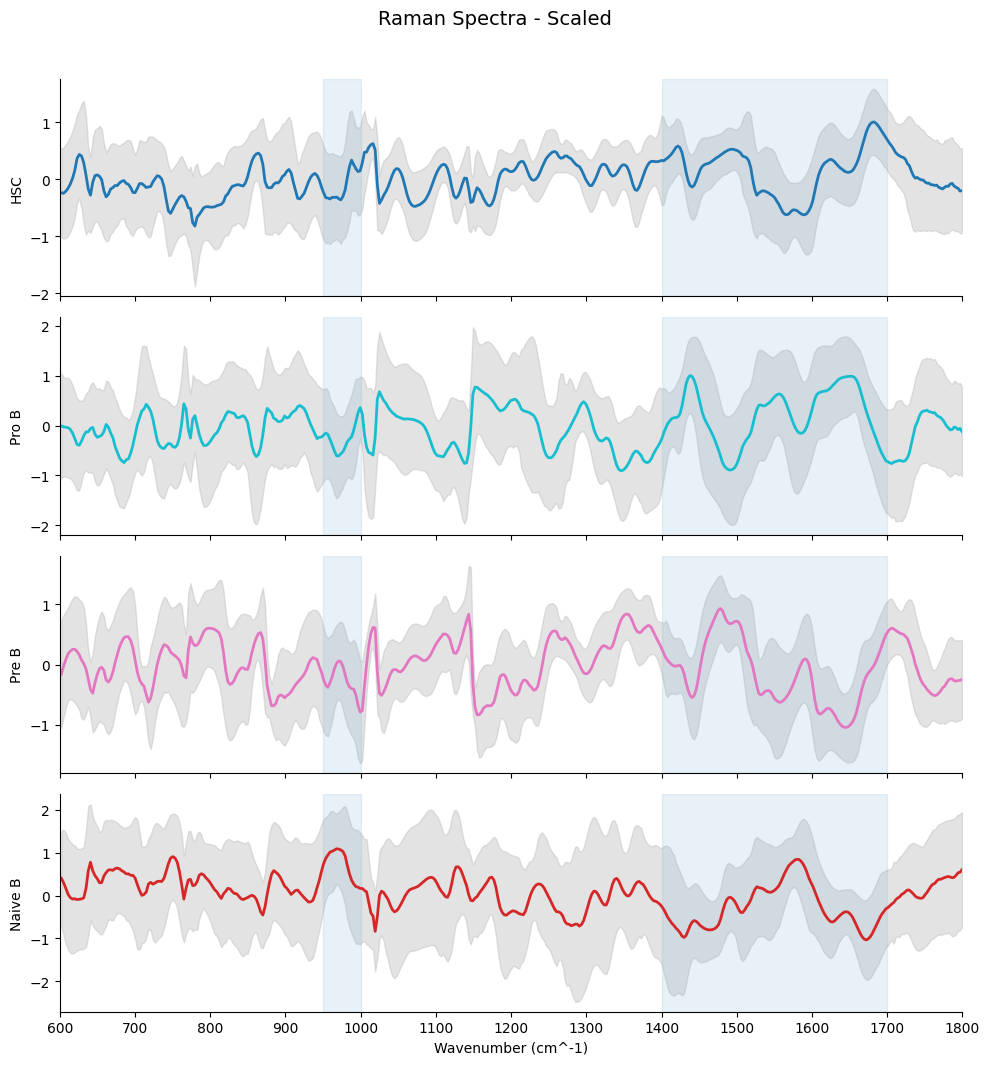

{'HSC': '#1f77b4',
 'Pro B': '#17becf',
 'Pre B': '#e377c2',
 'Naive B': '#d62728'}

In [105]:
raw_layer = "raw" if "raw" in adata_work.layers else None
df_raw = build_spectra_df(adata_work, layer=raw_layer, wn_min=600, wn_max=1800)
plot_facet_spectra_summary(
    df_raw, "Raman Spectra - Raw", highlight_ranges=highlight_ranges,
    output_dir=output_figS3, fname="raman_raw_spectra", color_map=class_color_map, order=ORDER
)

df_scaled = build_spectra_df(adata_work, layer=None, wn_min=600, wn_max=1800)
plot_facet_spectra_summary(
    df_scaled, "Raman Spectra - Scaled", highlight_ranges=highlight_ranges,
    output_dir=output_figS3, fname="raman_scaled_spectra", color_map=class_color_map, order=ORDER
)

## Excel Export (Raw / Scaled Mean Spectra)

In [106]:
def beautify_excel(workbook, sheet_name, df):
    ws = workbook[sheet_name]
    header_fill = PatternFill(start_color="D9E1F2", end_color="D9E1F2", fill_type="solid")
    header_font = Font(bold=True)
    border = Border(left=Side(style="thin"), right=Side(style="thin"),
                    top=Side(style="thin"), bottom=Side(style="thin"))
    center = Alignment(horizontal="center", vertical="center")

    for col in range(1, ws.max_column + 1):
        cell = ws.cell(row=1, column=col)
        cell.fill = header_fill
        cell.font = header_font
        cell.border = border
        cell.alignment = center

    for col_idx, col_name in enumerate(df.columns, start=1):
        max_len = max(len(str(col_name)), df[col_name].astype(str).map(len).max()) + 2
        ws.column_dimensions[ws.cell(row=1, column=col_idx).column_letter].width = min(max_len, 36)
        for row in range(2, ws.max_row + 1):
            cell = ws.cell(row=row, column=col_idx)
            cell.border = border
            if "mean" in col_name:
                cell.number_format = "0.000"
    ws.freeze_panes = "A2"

def export_spectra_table(raw_df, scaled_df, output_path):
    raw_mean = raw_df.groupby(["cell_type", "Wavenumber"]).agg(raw_mean=("Intensity", "mean")).reset_index()
    scaled_mean = scaled_df.groupby(["cell_type", "Wavenumber"]).agg(scaled_mean=("Intensity", "mean")).reset_index()
    merged = pd.merge(raw_mean, scaled_mean, on=["cell_type", "Wavenumber"], how="outer")

    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        merged.to_excel(writer, sheet_name="spectra_summary", index=False)
        beautify_excel(writer.book, "spectra_summary", merged)
    return merged

In [107]:
excel_path = output_figS3 / "spectra_summary.xlsx"
spectra_summary_df = export_spectra_table(df_raw, df_scaled, excel_path)
spectra_summary_df.head()

,cell_type,Wavenumber,raw_mean,scaled_mean
0,HSC,602.022,0.002739,-0.234123
1,HSC,605.013,0.004053,-0.242804
2,HSC,608.003,0.004637,-0.208270
3,HSC,610.992,0.005100,-0.156493
4,HSC,613.980,0.004977,-0.082557


## Differential Expression (Raman)

Export rank_genes_groups to results/figure2.

In [108]:
sc.tl.rank_genes_groups(adata_work, "cell_type", method="wilcoxon", layer="norm")
deg_df = sc.get.rank_genes_groups_df(adata_work, group=None)
deg_df.to_excel(output_fig2 / "raman_rank_genes_groups.xlsx", index=False)
deg_df.head()

g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
g:\C_pan_copy_dir\.conda\envs\scanpy_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,HSC,1682.59,22.538603,0.156392,1.737142e-112,7.504451e-110
1,HSC,1679.97,22.386749,0.151105,5.298437e-111,1.144462e-108
2,HSC,1685.21,22.308052,0.157287,3.086518e-110,4.444586e-108
3,HSC,1677.36,21.982323,0.144918,4.251488e-107,4.591607e-105
4,HSC,1687.82,21.754234,0.158531,6.298827e-105,5.442186e-103
